<a href="https://colab.research.google.com/github/asiddiqha/ai-workbench/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================================
# K-Nearest Neighbors (KNN) Classification
# ==========================================================

# ----------------------------------------------------------
# STEP 1 : Import Required Libraries
# ----------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ----------------------------------------------------------
# STEP 2 : Load Dataset
# ----------------------------------------------------------

df = pd.read_excel("KNN.xlsx")

df.head()

,Student_ID,Study_Hours,Attendance (%),Assignments_Submitted,Previous_Score,Pass
0,S001,2,55,3,40,No
1,S002,3,60,4,45,No
2,S003,1,50,2,35,No
3,S004,4,65,5,50,No
4,S005,5,68,6,55,No


In [3]:
# ----------------------------------------------------------
# STEP 3 : Dataset Overview
# ----------------------------------------------------------

print("Shape :", df.shape)

print("\nInformation")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Shape : (30, 6)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student_ID             30 non-null     object
 1   Study_Hours            30 non-null     int64 
 2   Attendance (%)         30 non-null     int64 
 3   Assignments_Submitted  30 non-null     int64 
 4   Previous_Score         30 non-null     int64 
 5   Pass                   30 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.5+ KB

Missing Values
Student_ID               0
Study_Hours              0
Attendance (%)           0
Assignments_Submitted    0
Previous_Score           0
Pass                     0
dtype: int64

Duplicate Rows : 0


In [4]:
# ----------------------------------------------------------
# STEP 4 : Statistical Summary
# ----------------------------------------------------------

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Study_Hours,30.0,5.633333,2.797577,1.0,3.25,5.5,8.0,10.0
Attendance (%),30.0,69.100000,11.420943,48.0,60.50,69.5,77.5,90.0
Assignments_Submitted,30.0,5.900000,2.682639,1.0,4.00,6.0,8.0,10.0
Previous_Score,30.0,56.466667,13.823352,30.0,45.75,57.0,67.5,80.0


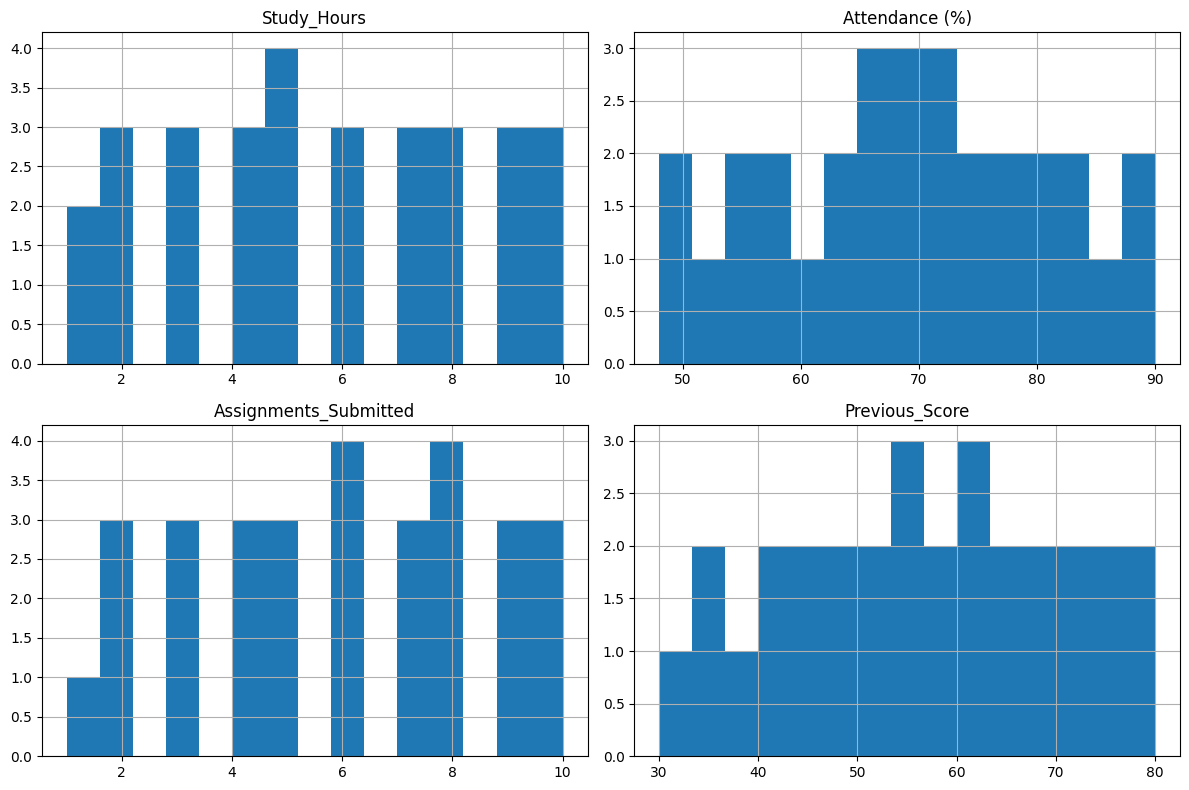

In [5]:
# ----------------------------------------------------------
# STEP 5 : Feature Distribution
# ----------------------------------------------------------

df.hist(figsize=(12,8), bins=15)

plt.tight_layout()

plt.show()

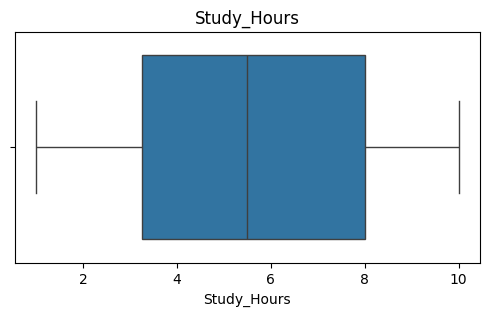

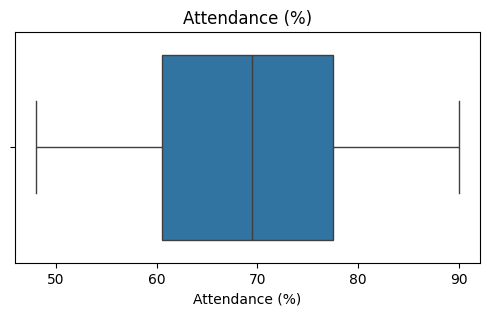

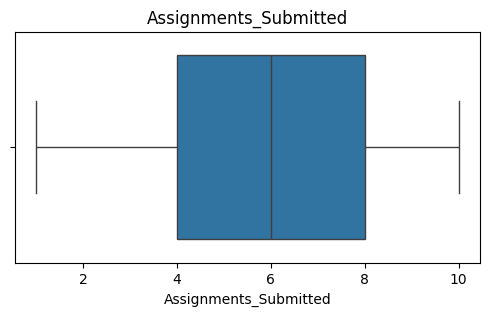

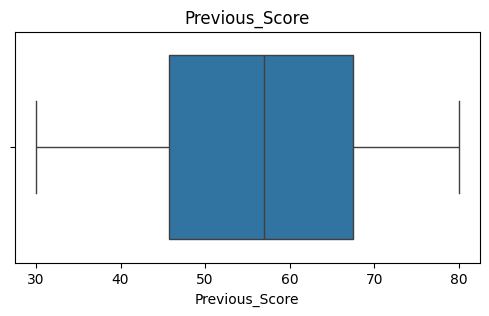

In [6]:
# ----------------------------------------------------------
# STEP 6 : Outlier Detection
# ----------------------------------------------------------

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

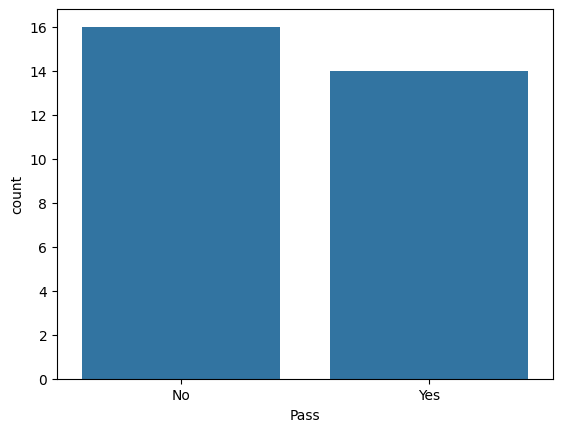

Pass
No     16
Yes    14
Name: count, dtype: int64


In [8]:
# ----------------------------------------------------------
# STEP 7 : Target Distribution
# ----------------------------------------------------------

sns.countplot(data=df, x="Pass")

plt.show()

print(df["Pass"].value_counts())

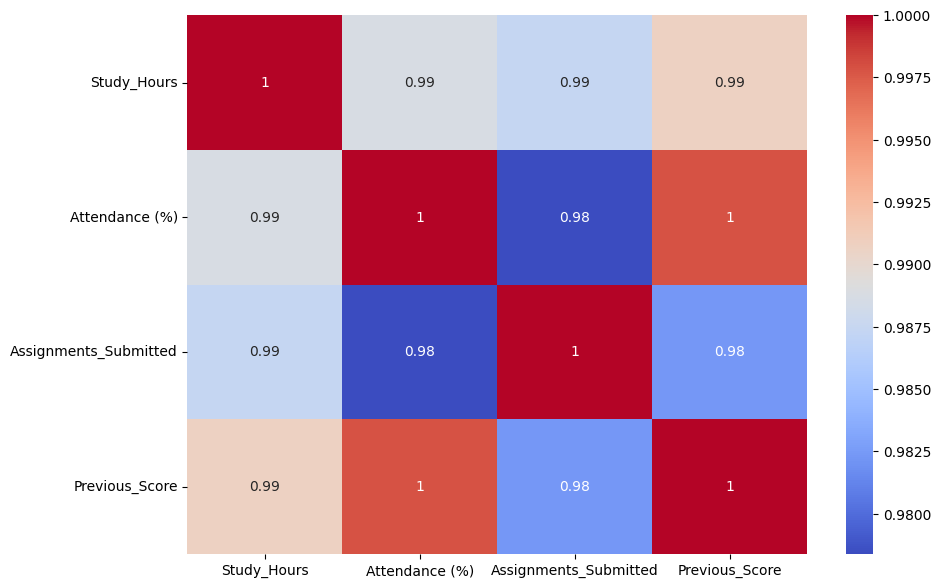

In [9]:
# ----------------------------------------------------------
# STEP 8 : Correlation Analysis
# ----------------------------------------------------------

plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

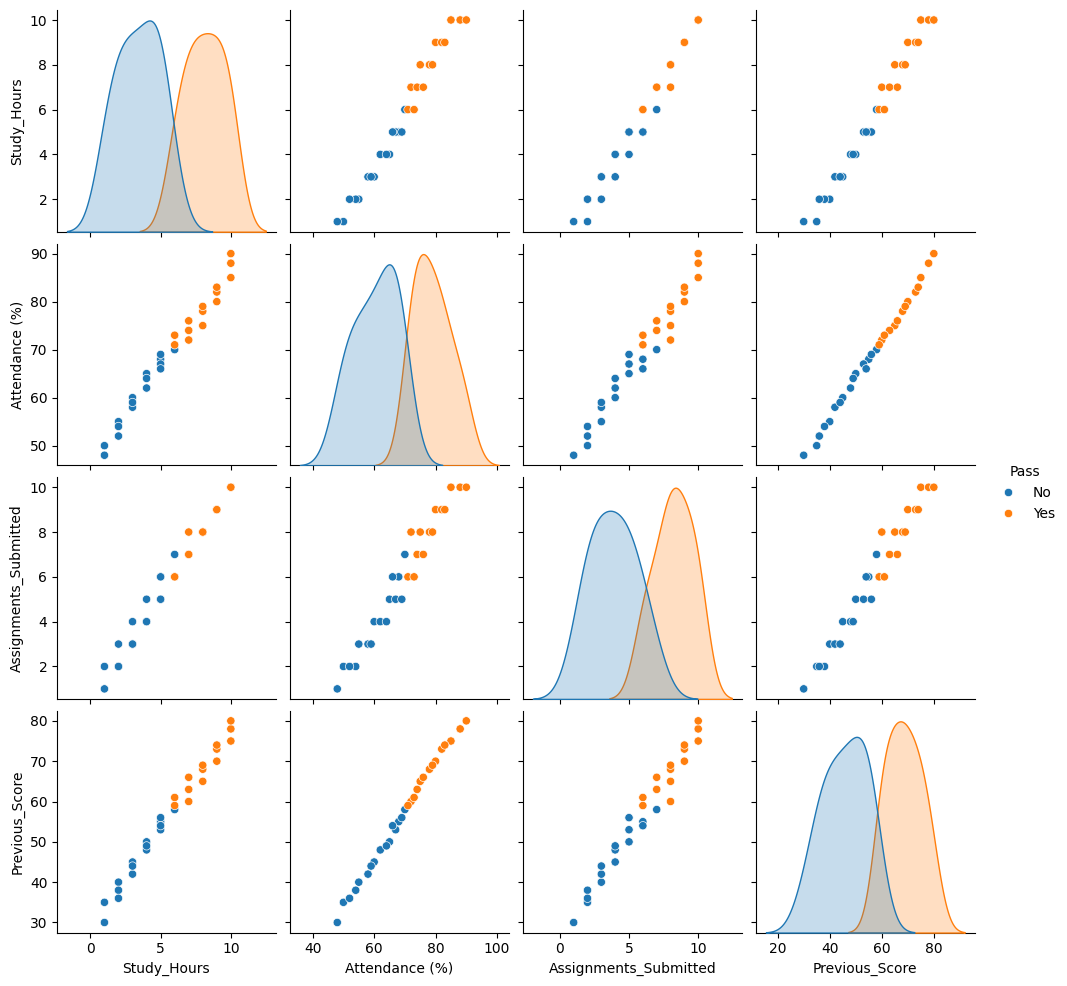

In [10]:
# ----------------------------------------------------------
# STEP 9 : Pairplot
# ----------------------------------------------------------

sns.pairplot(df, hue="Pass")

plt.show()

In [11]:
# ----------------------------------------------------------
# STEP 10 : Feature Engineering
# ----------------------------------------------------------

# Remove ID column if available

df.drop("Student_ID", axis=1, inplace=True)

# Encode target

encoder = LabelEncoder()

df["Pass"] = encoder.fit_transform(df["Pass"])

df.head()

,Study_Hours,Attendance (%),Assignments_Submitted,Previous_Score,Pass
0,2,55,3,40,0
1,3,60,4,45,0
2,1,50,2,35,0
3,4,65,5,50,0
4,5,68,6,55,0


In [12]:
# ----------------------------------------------------------
# STEP 11 : Feature Selection
# ----------------------------------------------------------

X = df.drop("Pass", axis=1)

y = df["Pass"]

In [13]:
# ----------------------------------------------------------
# STEP 12 : Train-Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# ----------------------------------------------------------
# STEP 13 : Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
# ----------------------------------------------------------
# STEP 14 : Find Optimal K
# ----------------------------------------------------------

accuracy = []

for k in range(1, 16):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy.append(accuracy_score(y_test, y_pred))

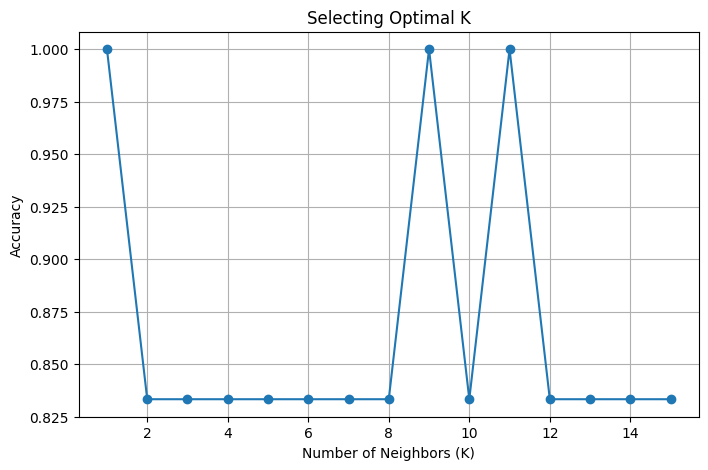

In [16]:
# ----------------------------------------------------------
# STEP 15 : Elbow Method
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    range(1,16),
    accuracy,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Accuracy")

plt.title("Selecting Optimal K")

plt.grid(True)

plt.show()

In [17]:
# ----------------------------------------------------------
# STEP 16 : Train KNN Model
# ----------------------------------------------------------

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [18]:
# ----------------------------------------------------------
# STEP 17 : Prediction
# ----------------------------------------------------------

y_pred = model.predict(X_test_scaled)

In [19]:
# ----------------------------------------------------------
# STEP 18 : Model Evaluation
# ----------------------------------------------------------

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report")

print(classification_report(y_test, y_pred))

Accuracy : 0.8333333333333334

Classification Report
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



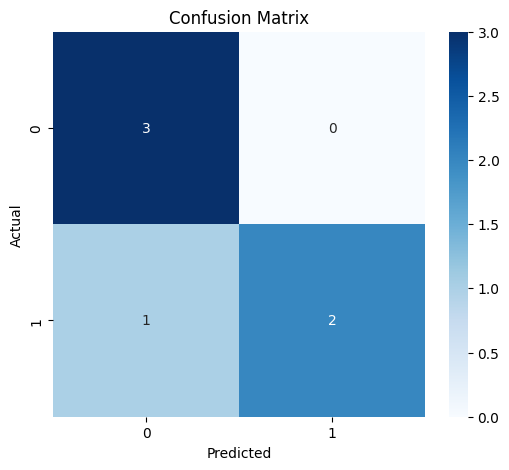

In [20]:
# ----------------------------------------------------------
# STEP 19 : Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()